# Milestone 0 — LIBERO Data Exploration

**NVIDIA Version: the FPS is 20, which is the correct version**

**Dataset:** `nvidia_libero_v3`

**Target task:** `put the bowl on the plate`

### Questions
1. What observations, states, and actions are stored?
2. How are language instructions associated with frames?
3. Which episodes correspond to the target task?
4. What does one complete demonstration look like?
5. How do robot state and actions evolve through the trajectory?

### Observation
- The recorded demonstrations are stored at 20 Hz, corresponding to one
dataset frame every 0.05 s.

### Data representation

At each timestep the dataset contains: $o_t =\{I_t^{external},I_t^{wrist},s_t\}$, and an expert action $a_t \in \mathbb{R}^7.$

### Task
| Task | Task Index | # of demonstration |
| :-------- | :-------: | :------: |
| put the bowl on the plate | 0 | 49 |

### Examine One Episode
The bowl is gray while the plate is white with brownish edge. From the external camera, the distance of the robot arm relative to other objects can be clearly seen, while the wrist camera may be well suited for fine-tuning the distance between the end-effector and the bowl or plate.

In [2]:
import json
from pathlib import Path

root = Path(
    "~/ML/robot-learning-project1/"
    "data/nvidia_libero_v3/libero_goal"
).expanduser()

with open(root / "meta/info.json") as f:
    info = json.load(f)

print("FPS:", info["fps"])
print("Episodes:", info["total_episodes"])
print("Frames:", info["total_frames"])
print("Features:")

for key, value in info["features"].items():
    print(key, value)
    print()


FPS: 20
Episodes: 428
Frames: 52042
Features:
observation.images.wrist_image {'dtype': 'video', 'shape': [256, 256, 3], 'names': ['height', 'width', 'rgb'], 'info': {'video.height': 256, 'video.width': 256, 'video.codec': 'av1', 'video.pix_fmt': 'yuv420p', 'video.is_depth_map': False, 'video.fps': 20, 'video.channels': 3, 'has_audio': False}}

observation.images.image {'dtype': 'video', 'shape': [256, 256, 3], 'names': ['height', 'width', 'rgb'], 'info': {'video.height': 256, 'video.width': 256, 'video.codec': 'av1', 'video.pix_fmt': 'yuv420p', 'video.is_depth_map': False, 'video.fps': 20, 'video.channels': 3, 'has_audio': False}}

observation.state {'dtype': 'float32', 'shape': [8], 'names': {'motors': ['x', 'y', 'z', 'axis_angle1', 'axis_angle2', 'axis_angle3', 'gripper', 'gripper']}, 'fps': 20}

action {'dtype': 'float32', 'shape': [7], 'names': {'motors': ['x', 'y', 'z', 'axis_angle1', 'axis_angle2', 'axis_angle3', 'gripper']}, 'fps': 20}

timestamp {'dtype': 'float32', 'shape': [1

In [3]:
import pandas as pd

root = Path(
    "~/ML/robot-learning-project1/data/nvidia_libero_v3/libero_goal"
).expanduser()

tasks_path = root / "meta/tasks.parquet"

tasks = pd.read_parquet(tasks_path)

print(type(tasks))
print(tasks)

<class 'pandas.core.frame.DataFrame'>
                                             task_index
put the bowl on the plate                             0
put the wine bottle on the rack                       1
open the top drawer and put the bowl inside           2
put the cream cheese in the bowl                      3
put the wine bottle on top of the cabinet             4
push the plate to the front of the stove              5
turn on the stove                                     6
put the bowl on the stove                             7
put the bowl on top of the cabinet                    8
open the middle drawer of the cabinet                 9


In [4]:
print("Columns:", tasks.columns.tolist())
print("Index name:", tasks.index.name)

display(tasks.reset_index())

Columns: ['task_index']
Index name: None


,index,task_index
0,put the bowl on the plate,0
1,put the wine bottle on the rack,1
2,open the top drawer and put the bowl inside,2
3,put the cream cheese in the bowl,3
4,put the wine bottle on top of the cabinet,4
5,push the plate to the front of the stove,5
6,turn on the stove,6
7,put the bowl on the stove,7
8,put the bowl on top of the cabinet,8
9,open the middle drawer of the cabinet,9


In [5]:
import pyarrow.parquet as pq

schema = pq.read_schema(tasks_path)
print(schema)

task_index: int64
__index_level_0__: string
-- schema metadata --
pandas: '{"index_columns": ["__index_level_0__"], "column_indexes": [{"na' + 467


In [11]:
TARGET_TASK_INDEX = 0
REPO_ID = "nvidia/LIBERO_LeRobot_v3"

In [8]:
import numpy as np

from lerobot.datasets import LeRobotDataset

SRC_ROOT = (
    Path("~/ML/robot-learning-project1/"
         "data/nvidia_libero_v3/libero_goal")
    .expanduser()
)

src = LeRobotDataset(
    repo_id="nvidia/LIBERO_LeRobot_v3",
    root=SRC_ROOT,
    download_videos=False,
)

actions = np.asarray(
    src.hf_dataset["action"],
    dtype=np.float32,
)

task_indices = np.asarray(
    src.hf_dataset["task_index"]
)

target_actions = actions[
    task_indices == TARGET_TASK_INDEX
]

gripper = target_actions[:, -1]

print("Gripper min:", gripper.min())
print("Gripper max:", gripper.max())
print("Unique values:", np.unique(gripper))

Gripper min: 0.0
Gripper max: 1.0
Unique values: [0. 1.]


In [9]:
import matplotlib.pyplot as plt
import torch

from lerobot.datasets import LeRobotDatasetMetadata

In [10]:
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 5060 Laptop GPU


In [13]:
meta = LeRobotDatasetMetadata(
    repo_id="nvidia/LIBERO_LeRobot_v3",
    root=SRC_ROOT)

print("Repository:", REPO_ID)
print("Episodes:", meta.total_episodes)
print("Frames:", meta.total_frames)
print("FPS:", meta.fps)
print("Robot type:", meta.robot_type)

Repository: nvidia/LIBERO_LeRobot_v3
Episodes: 428
Frames: 52042
FPS: 20
Robot type: franka


In [14]:
for key, value in meta.features.items():
    print(f"{key}:")
    print(value)
    print()

observation.images.wrist_image:
{'dtype': 'video', 'shape': (256, 256, 3), 'names': ['height', 'width', 'rgb'], 'info': {'video.height': 256, 'video.width': 256, 'video.codec': 'av1', 'video.pix_fmt': 'yuv420p', 'video.is_depth_map': False, 'video.fps': 20, 'video.channels': 3, 'has_audio': False}}

observation.images.image:
{'dtype': 'video', 'shape': (256, 256, 3), 'names': ['height', 'width', 'rgb'], 'info': {'video.height': 256, 'video.width': 256, 'video.codec': 'av1', 'video.pix_fmt': 'yuv420p', 'video.is_depth_map': False, 'video.fps': 20, 'video.channels': 3, 'has_audio': False}}

observation.state:
{'dtype': 'float32', 'shape': (8,), 'names': {'motors': ['x', 'y', 'z', 'axis_angle1', 'axis_angle2', 'axis_angle3', 'gripper', 'gripper']}, 'fps': 20}

action:
{'dtype': 'float32', 'shape': (7,), 'names': {'motors': ['x', 'y', 'z', 'axis_angle1', 'axis_angle2', 'axis_angle3', 'gripper']}, 'fps': 20}

timestamp:
{'dtype': 'float32', 'shape': (1,), 'names': None, 'fps': 20}

frame_in

In [15]:
tasks = meta.tasks.reset_index()

print(tasks.columns)
display(tasks.head())

Index(['task', 'task_index'], dtype='object')


,task,task_index
0,put the bowl on the plate,0
1,put the wine bottle on the rack,1
2,open the top drawer and put the bowl inside,2
3,put the cream cheese in the bowl,3
4,put the wine bottle on top of the cabinet,4


In [16]:
task_text_col = tasks.columns[0]

tasks = tasks.sort_values("task_index").reset_index(drop=True)

display(tasks)

,task,task_index
0,put the bowl on the plate,0
1,put the wine bottle on the rack,1
2,open the top drawer and put the bowl inside,2
3,put the cream cheese in the bowl,3
4,put the wine bottle on top of the cabinet,4
5,push the plate to the front of the stove,5
6,turn on the stove,6
7,put the bowl on the stove,7
8,put the bowl on top of the cabinet,8
9,open the middle drawer of the cabinet,9


### Inspect the episode belonging to task 0
Loading the dataset without videos

In [18]:
dataset_tabular = src
print(src)

LeRobotDataset({
    Repository ID: 'nvidia/LIBERO_LeRobot_v3',
    Number of selected episodes: '428',
    Number of selected samples: '52042',
    Features: '['observation.images.wrist_image', 'observation.images.image', 'observation.state', 'action', 'timestamp', 'frame_index', 'episode_index', 'index', 'task_index']',
})


In [19]:
hf = dataset_tabular.hf_dataset

task_indices = np.asarray(hf["task_index"])
episode_indices = np.asarray(hf["episode_index"])

print("task_indices shape:", task_indices.shape)
print("episode_indices shape:", episode_indices.shape)

task_indices shape: (52042,)
episode_indices shape: (52042,)


In [20]:
print("TARGET_TASK_INDEX:", TARGET_TASK_INDEX)
target_episode_ids = np.unique(
    episode_indices[task_indices == TARGET_TASK_INDEX]
)

print("Number of target episodes:", len(target_episode_ids))
print("Episode IDs:")
print(target_episode_ids)

TARGET_TASK_INDEX: 0
Number of target episodes: 49
Episode IDs:
[  0  43  47  52  54  68  69  72  80  87 102 104 109 128 132 134 143 153
 158 170 172 184 189 203 228 236 241 242 247 255 260 263 267 274 276 291
 300 329 337 339 347 348 370 371 389 391 422 424 427]


In [21]:
episode_lengths = []

for ep_id in target_episode_ids:
    count = np.sum(episode_indices == ep_id)
    episode_lengths.append(count)

episode_lengths = np.asarray(episode_lengths)

print("Number of episodes:", len(episode_lengths))
print("Mean length:", episode_lengths.mean())
print("Min length:", episode_lengths.min())
print("Max length:", episode_lengths.max())

print(
    "Mean duration:",
    episode_lengths.mean() / meta.fps,
    "seconds"
)



Number of episodes: 49
Mean length: 93.12244897959184
Min length: 79
Max length: 126
Mean duration: 4.656122448979592 seconds


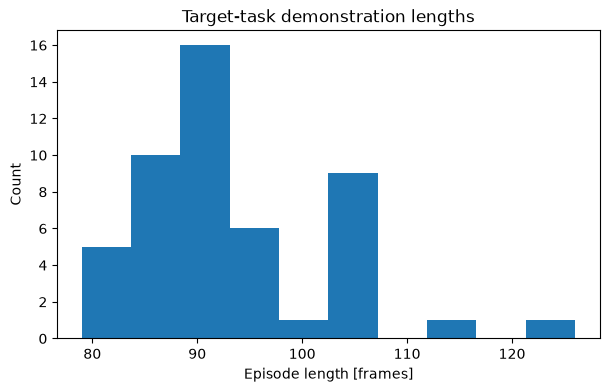

In [22]:
plt.figure(figsize=(7, 4))
plt.hist(episode_lengths)
plt.xlabel("Episode length [frames]")
plt.ylabel("Count")
plt.title("Target-task demonstration lengths")
plt.show()

### Examine One Episode

In [23]:
EPISODE_ID = int(target_episode_ids[0])

print("Exploring episode:", EPISODE_ID)

episode = LeRobotDataset(
    repo_id="nvidia/LIBERO_LeRobot_v3",
    root=SRC_ROOT,
    episodes=[EPISODE_ID],
)

print(episode)
print("Number of frames:", len(episode))


Exploring episode: 0
LeRobotDataset({
    Repository ID: 'nvidia/LIBERO_LeRobot_v3',
    Number of selected episodes: '1',
    Number of selected samples: '112',
    Features: '['observation.images.wrist_image', 'observation.images.image', 'observation.state', 'action', 'timestamp', 'frame_index', 'episode_index', 'index', 'task_index']',
})
Number of frames: 112


In [24]:
sample = episode[0]

for key, value in sample.items():
    if hasattr(value, "shape"):
        print(
            f"{key:35s}",
            "shape =", tuple(value.shape),
            "dtype =", value.dtype,
        )
    else:
        print(key, type(value), value)

observation.images.wrist_image      shape = (3, 256, 256) dtype = torch.float32
observation.images.image            shape = (3, 256, 256) dtype = torch.float32
observation.state                   shape = (8,) dtype = torch.float32
action                              shape = (7,) dtype = torch.float32
timestamp                           shape = () dtype = torch.float32
frame_index                         shape = () dtype = torch.int64
episode_index                       shape = () dtype = torch.int64
index                               shape = () dtype = torch.int64
task_index                          shape = () dtype = torch.int64
task <class 'str'> put the bowl on the plate


In [25]:
def image_to_numpy(img):
    if torch.is_tensor(img):
        img = img.detach().cpu()

    img = np.asarray(img)

    # CHW -> HWC
    if img.ndim == 3 and img.shape[0] in (1, 3, 4):
        img = np.transpose(img, (1, 2, 0))

    # Handle float image tensors
    if np.issubdtype(img.dtype, np.floating):
        img = np.clip(img, 0.0, 1.0)

    return img


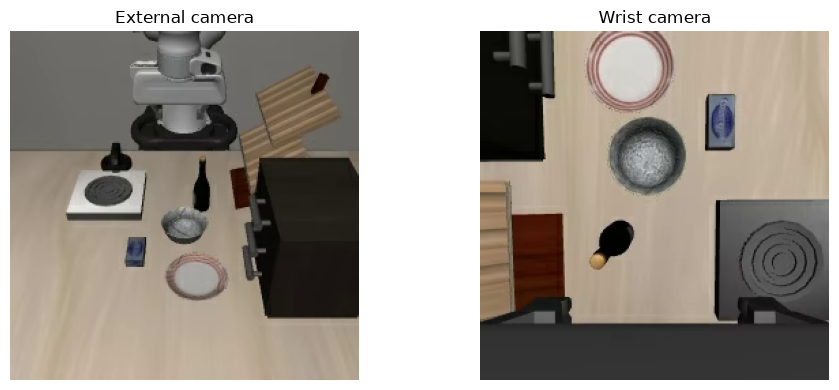

In [26]:
main_img = image_to_numpy(
    sample["observation.images.image"]
)

wrist_img = image_to_numpy(
    sample["observation.images.wrist_image"]
)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(main_img)
axes[0].set_title("External camera")
axes[0].axis("off")

axes[1].imshow(wrist_img)
axes[1].set_title("Wrist camera")
axes[1].axis("off")

plt.tight_layout()
plt.show()


In [27]:
state = sample["observation.state"]
action = sample["action"]

print("State:")
print(state)

print("\nAction:")
print(action)


State:
tensor([-0.2030,  0.0103,  1.1777,  3.1398,  0.0043, -0.0928,  0.0388, -0.0388])

Action:
tensor([ 0.0723,  0.0000, -0.0000, -0.0118,  0.0439,  0.0354,  1.0000])


In [28]:
STATE_NAMES = [
    "eef_x",
    "eef_y",
    "eef_z",
    "axis_angle_x",
    "axis_angle_y",
    "axis_angle_z",
    "gripper_0",
    "gripper_1",
]

for name, value in zip(STATE_NAMES, state):
    print(f"{name:16s}: {float(value): .4f}")


eef_x           : -0.2030
eef_y           :  0.0103
eef_z           :  1.1777
axis_angle_x    :  3.1398
axis_angle_y    :  0.0043
axis_angle_z    : -0.0928
gripper_0       :  0.0388
gripper_1       : -0.0388


In [29]:
ACTION_NAMES = [
    "delta_x",
    "delta_y",
    "delta_z",
    "delta_rot_1",
    "delta_rot_2",
    "delta_rot_3",
    "gripper",
]

for name, value in zip(ACTION_NAMES, action):
    print(f"{name:16s}: {float(value): .4f}")


delta_x         :  0.0723
delta_y         :  0.0000
delta_z         : -0.0000
delta_rot_1     : -0.0118
delta_rot_2     :  0.0439
delta_rot_3     :  0.0354
gripper         :  1.0000


In [30]:
frame_ids = np.linspace(
    0,
    len(episode) - 1,
    6,
    dtype=int,
)

frame_ids

array([  0,  22,  44,  66,  88, 111])

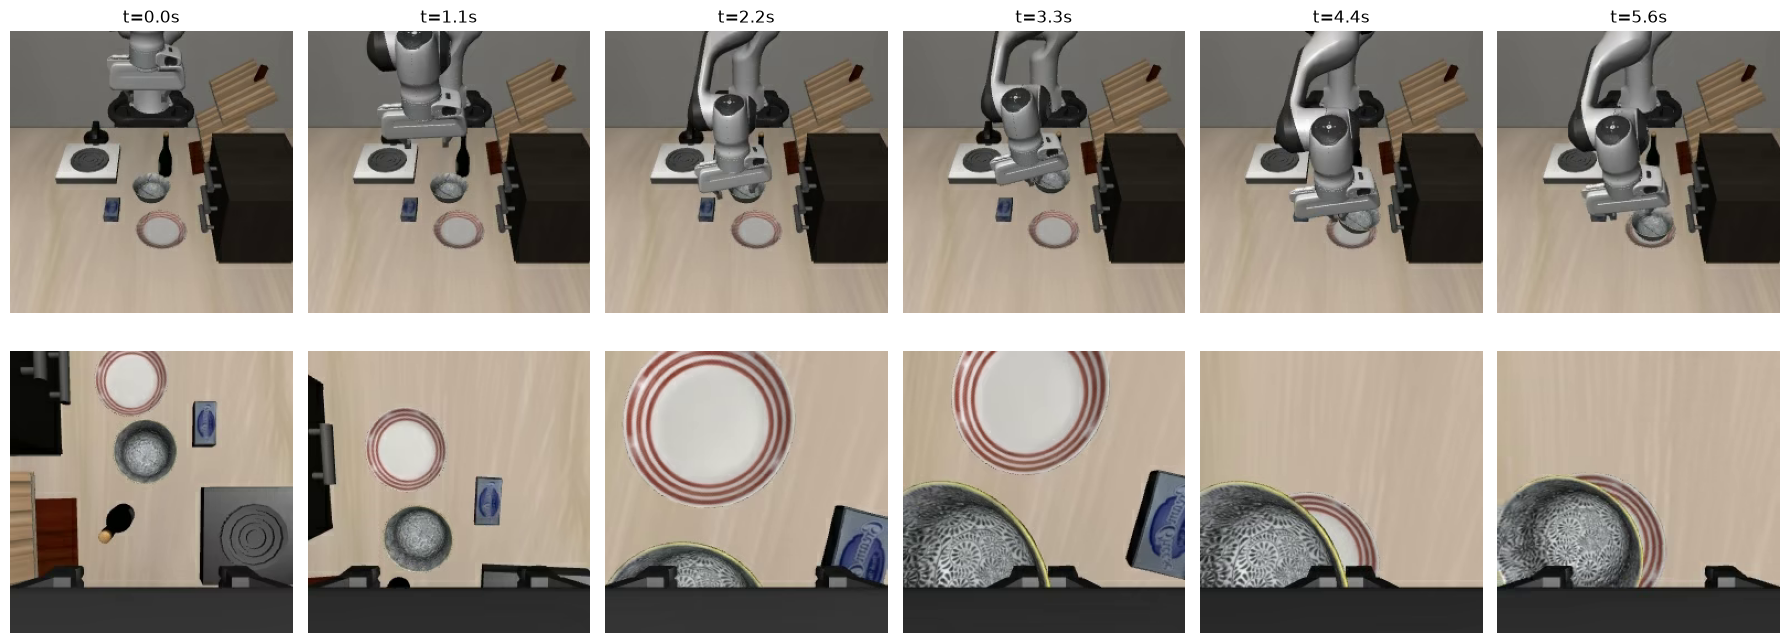

In [32]:
fig, axes = plt.subplots(
    2,
    len(frame_ids),
    figsize=(18, 7),
)

for col, idx in enumerate(frame_ids):
    frame = episode[idx]

    main = image_to_numpy(
        frame["observation.images.image"]
    )
    wrist = image_to_numpy(
        frame["observation.images.wrist_image"]
    )

    t = float(frame["timestamp"])

    axes[0, col].imshow(main)
    axes[0, col].set_title(f"t={t:.1f}s")

    axes[1, col].imshow(wrist)

    axes[0, col].axis("off")
    axes[1, col].axis("off")

axes[0, 0].set_ylabel("External")
axes[1, 0].set_ylabel("Wrist")

plt.tight_layout()
plt.show()


#### Qualitative interpretation

Based on the sampled frames, the episode appears to contain approximately:

0. initial position
1. scene observation / approach
2. alignment with bowl
3. grasp
4. lifting / transport
5. positioning over plate
6. release

These phases are inferred from visual inspection and are not provided as
ground-truth subtask labels.


In [33]:
raw_frames = [ episode.get_raw_item(i) for i in range(len(episode))]

actions = np.stack([np.asarray(f["action"]) for f in raw_frames])

states = np.stack([np.asarray(f["observation.state"]) for f in raw_frames])

timestamps = np.asarray([float(f["timestamp"]) for f in raw_frames])

print("actions:", actions.shape)
print("states:", states.shape)
print("timestamps:", timestamps.shape)


actions: (112, 7)
states: (112, 8)
timestamps: (112,)


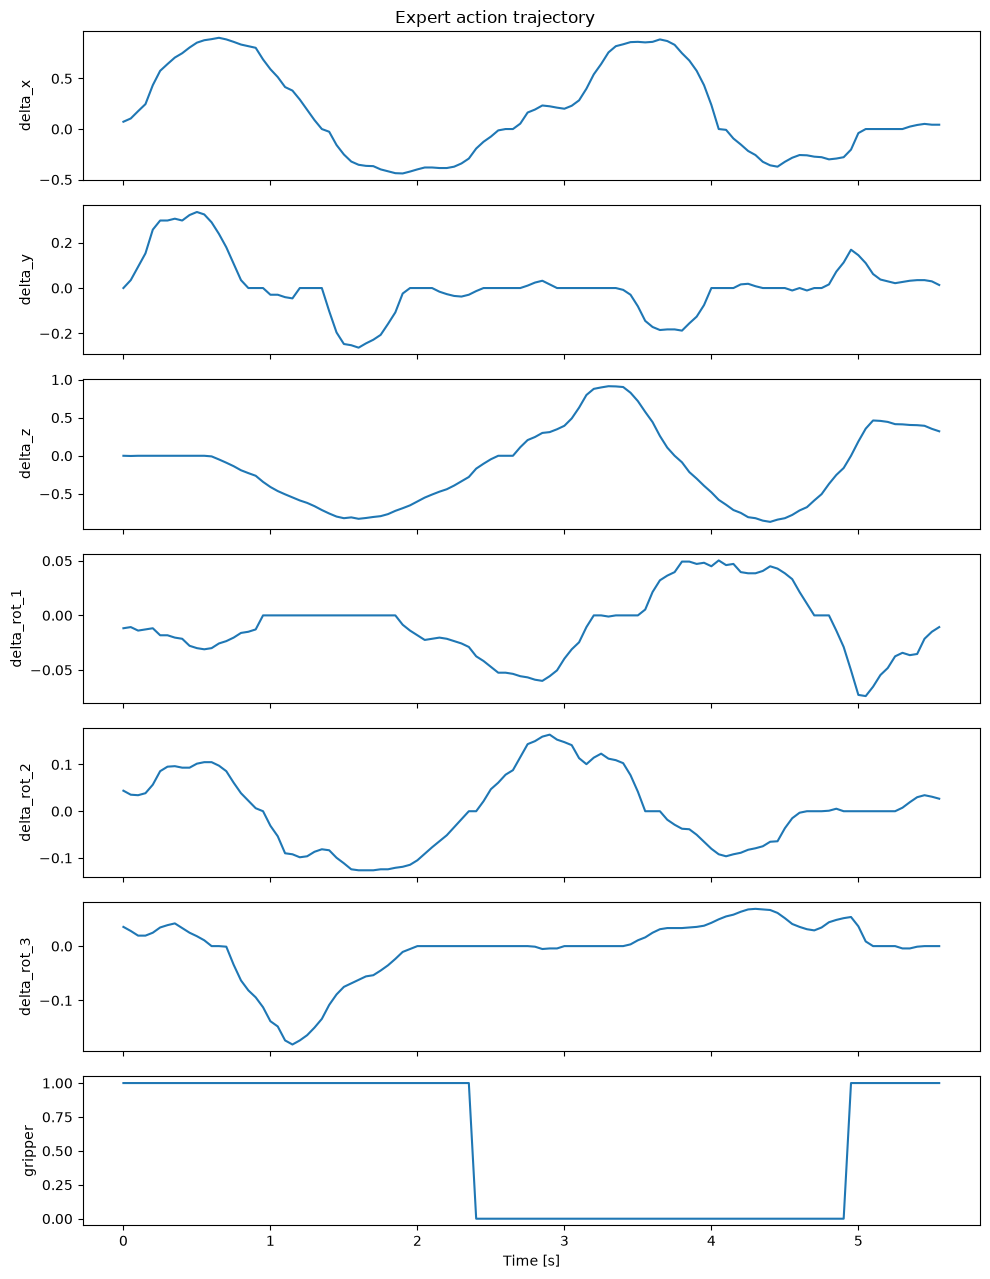

In [34]:
fig, axes = plt.subplots(
    7,
    1,
    figsize=(10, 13),
    sharex=True,
)

for i, ax in enumerate(axes):
    ax.plot(timestamps, actions[:, i])
    ax.set_ylabel(ACTION_NAMES[i])

axes[-1].set_xlabel("Time [s]")

fig.suptitle("Expert action trajectory")
plt.tight_layout()
plt.show()


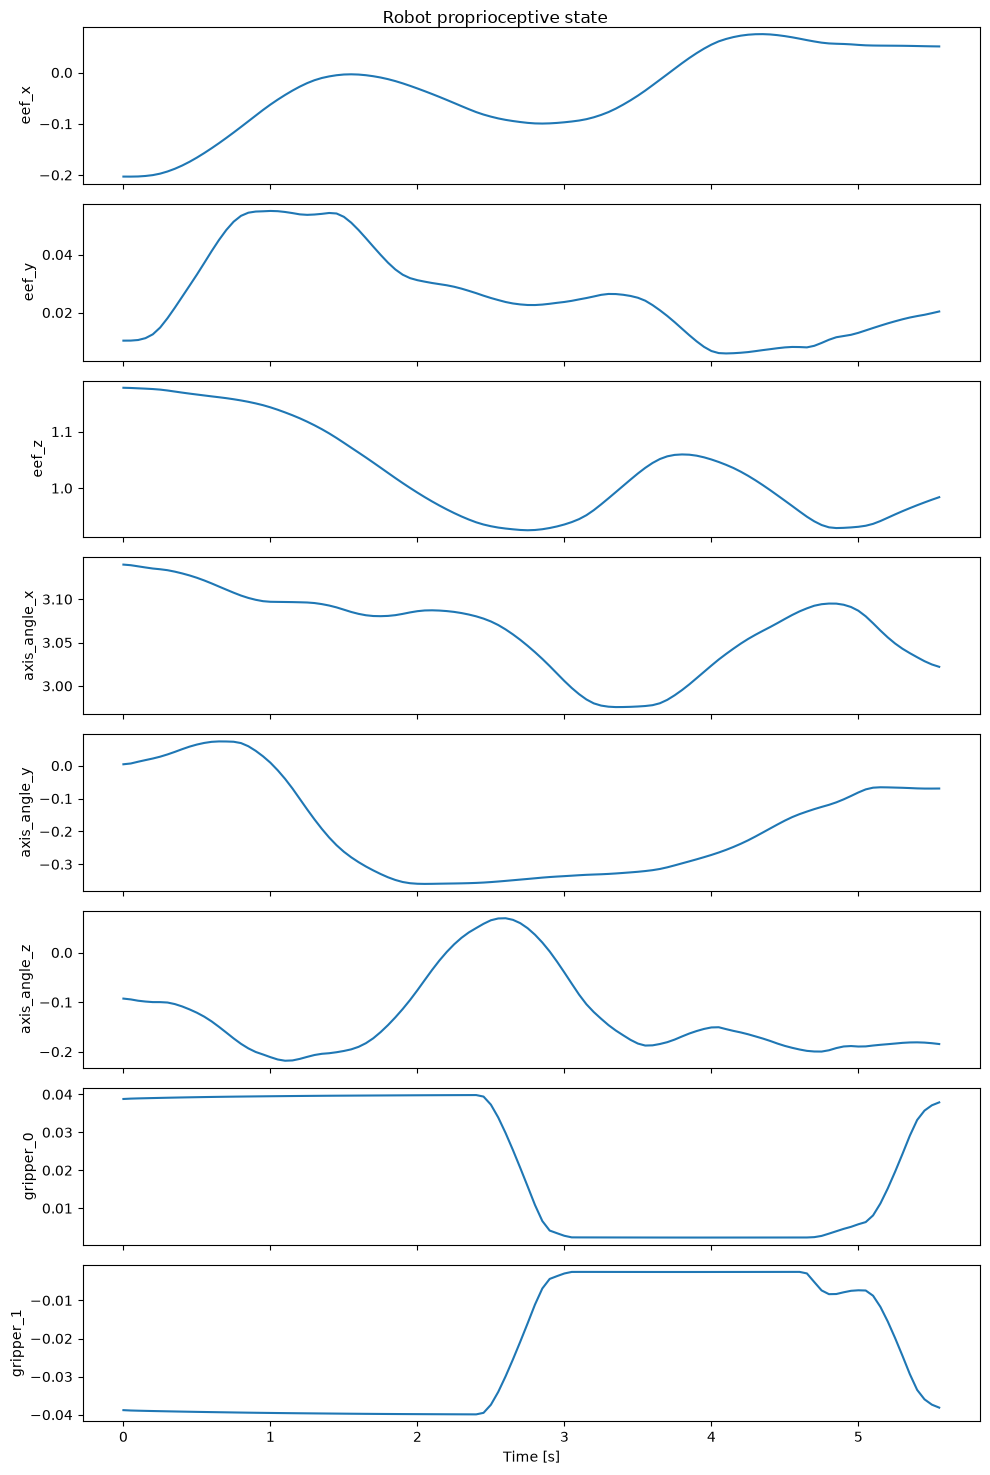

In [35]:
fig, axes = plt.subplots(
    8,
    1,
    figsize=(10, 15),
    sharex=True,
)

for i, ax in enumerate(axes):
    ax.plot(timestamps, states[:, i])
    ax.set_ylabel(STATE_NAMES[i])

axes[-1].set_xlabel("Time [s]")

fig.suptitle("Robot proprioceptive state")
plt.tight_layout()
plt.show()


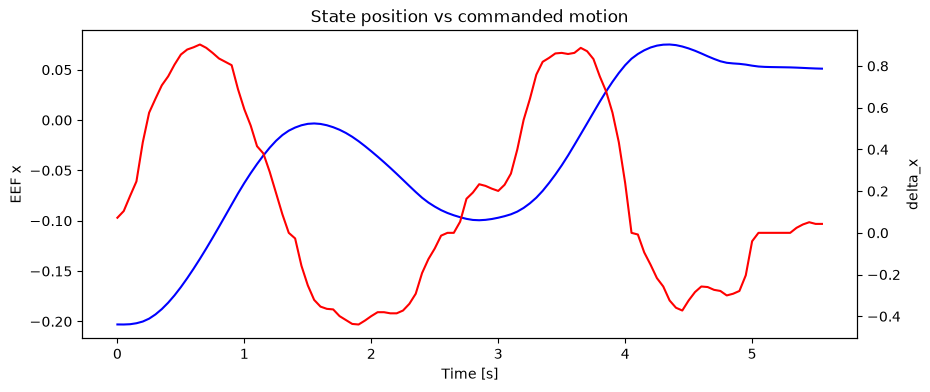

In [36]:
fig, ax1 = plt.subplots(figsize=(10, 4))

ax1.plot(timestamps, states[:, 0], label="EEF x", color = 'b')
ax1.set_xlabel("Time [s]")
ax1.set_ylabel("EEF x")

ax2 = ax1.twinx()
ax2.plot(timestamps, actions[:, 0], label="delta_x", color = 'r')
ax2.set_ylabel("delta_x")

plt.title("State position vs commanded motion")
plt.show()

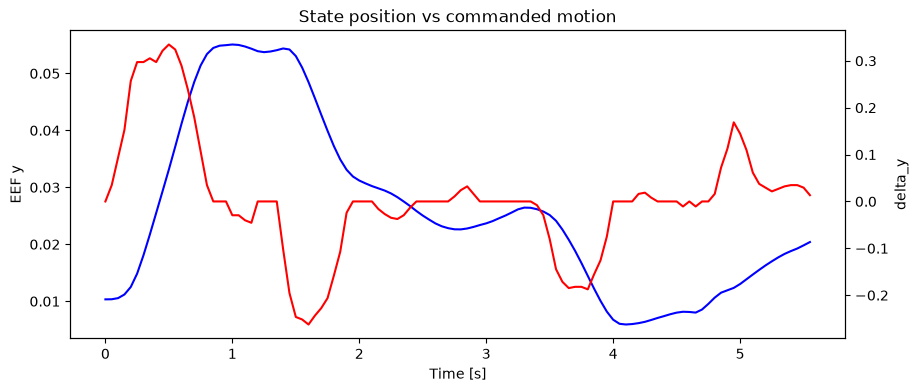

In [37]:
fig, ax1 = plt.subplots(figsize=(10, 4))

ax1.plot(timestamps, states[:, 1], label="EEF y", color = 'b')
ax1.set_xlabel("Time [s]")
ax1.set_ylabel("EEF y")

ax2 = ax1.twinx()
ax2.plot(timestamps, actions[:, 1], label="delta_y", color = 'r')
ax2.set_ylabel("delta_y")

plt.title("State position vs commanded motion")
plt.show()

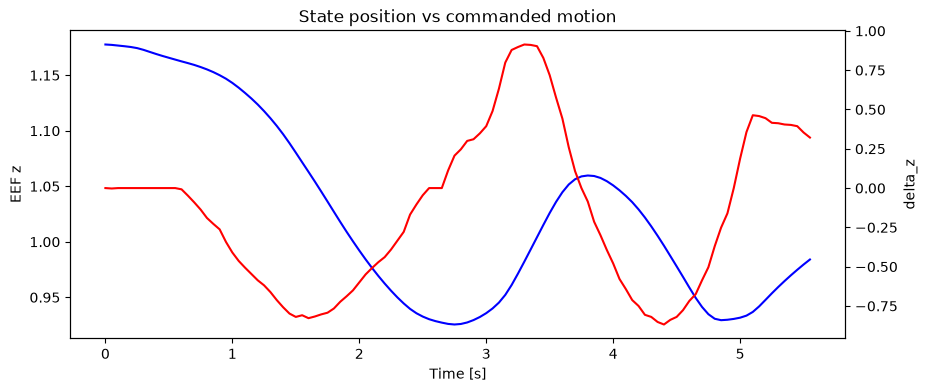

In [38]:
fig, ax1 = plt.subplots(figsize=(10, 4))

ax1.plot(timestamps, states[:, 2], label="EEF z", color = 'b')
ax1.set_xlabel("Time [s]")
ax1.set_ylabel("EEF z")

ax2 = ax1.twinx()
ax2.plot(timestamps, actions[:, 2], label="delta_z", color = 'r')
ax2.set_ylabel("delta_z")

plt.title("State position vs commanded motion")
plt.show()

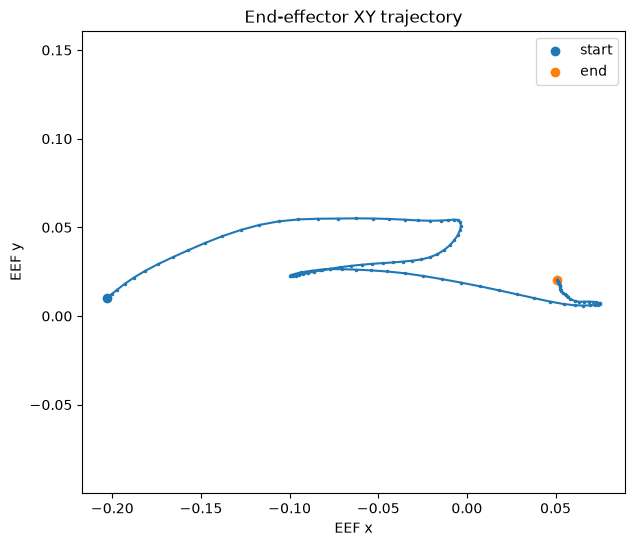

In [39]:
plt.figure(figsize=(7, 6))

plt.plot(
    states[:, 0],
    states[:, 1],
    marker=".",
    markersize=3,
)

plt.scatter(
    states[0, 0],
    states[0, 1],
    label="start",
)

plt.scatter(
    states[-1, 0],
    states[-1, 1],
    label="end",
)

plt.xlabel("EEF x")
plt.ylabel("EEF y")
plt.title("End-effector XY trajectory")
plt.legend()
plt.axis("equal")
plt.show()


In [40]:
episode_task_indices = np.unique([
    int(f["task_index"])
    for f in raw_frames
])

print("Task indices in episode:", episode_task_indices)


Task indices in episode: [0]


## Initial Findings

### Dataset
- Dataset: `nvidia_libero_v3`
- Stored frequency: 20 Hz
- Target task: put the bowl on the plate
- Task index: 0
- Number of demonstrations for the task: 49
- Mean demonstration duration: 4.65 s

### Observations
The policy receives:
- external RGB camera
- wrist RGB camera
- 8-D proprioceptive robot state

### Actions
Each timestep contains a 7-D expert action consisting of a 6-D
end-effector command and one gripper command.

### Qualitative task phases
The demonstration appears to consist of:

0. initial position
1. scene observation / approach
2. alignment with bowl
3. grasp
4. lifting / transport
5. positioning over plate
6. release

### Questions for ACT training
- What action-chunk horizon should ACT use?
- How are state/action features normalized?
- How does LeRobot align future action chunks near episode boundaries?


In [41]:
timestamps = np.array([
    float(episode.get_raw_item(i)["timestamp"])
    for i in range(len(episode))
])

dt = np.diff(timestamps)

print("Mean dt:", dt.mean())
print("Median dt:", np.median(dt))
print("Min dt:", dt.min())
print("Max dt:", dt.max())
print("Implied FPS:", 1.0 / np.median(dt))

Mean dt: 0.050000001718332104
Median dt: 0.04999995231628418
Min dt: 0.04999971389770508
Max dt: 0.05000019073486328
Implied FPS: 20.000019073504518


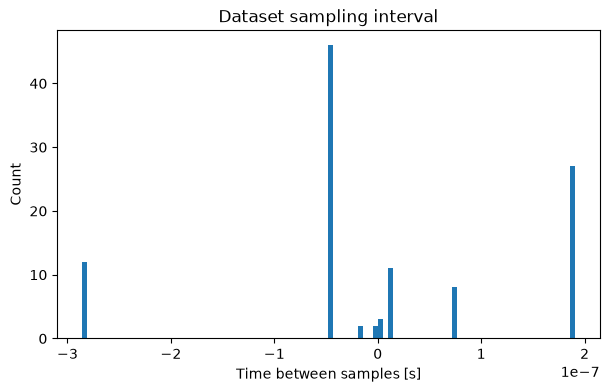

In [43]:
plt.figure(figsize=(7, 4))
plt.hist(dt-0.05, bins=100)
plt.xlabel("Time between samples [s]")
plt.ylabel("Count")
plt.title("Dataset sampling interval")
plt.show()

In [44]:
DATASET_FPS = meta.fps
ENV_FPS = 20

print(f"Dataset FPS: {DATASET_FPS}")
print(f"Dataset timestep: {1 / DATASET_FPS:.3f} s")

print(f"Environment FPS: {ENV_FPS}")
print(f"Environment timestep: {1 / ENV_FPS:.3f} s")

Dataset FPS: 20
Dataset timestep: 0.050 s
Environment FPS: 20
Environment timestep: 0.050 s


## Session 0M — Temporal Sampling

The NVIDIA LIBERO demonstrations are stored at 200 Hz:

- dataset timestep = 0.05 s
- images, state, and actions share the same sampling rate

The LIBERO simulation environment defaults to 20-Hz control:

- environment timestep = 0.05 s

I will not artificially upsample the demonstrations. In particular,
duplicating the 7-D relative actions would change their physical meaning.

For ACT training, temporal action targets are selected using the dataset
FPS. Therefore, at 20 Hz:

- 10-action chunk = 0.5 s
- 20-action chunk = 1.0 s
- 50-action chunk = 2.5 s

The choice of `chunk_size` and `n_action_steps` will therefore determine
the prediction horizon and the amount of open-loop execution.

In [45]:
from libero.libero import benchmark

suite = benchmark.get_benchmark_dict()["libero_goal"]()

TARGET_TASK_ID = 8

init_states = suite.get_task_init_states(TARGET_TASK_ID)

print(type(init_states))
print(init_states.shape)
print("Number of benchmark initial states:", len(init_states))


[info] using task orders [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
<class 'numpy.ndarray'>
(50, 79)
Number of benchmark initial states: 50


In [49]:
import pandas as pd
from pathlib import Path
from libero.libero import benchmark


# -----------------------------------------
# LIBERO benchmark side
# -----------------------------------------

LIBERO_TASK_ID = 8

suite = benchmark.get_benchmark_dict()["libero_goal"]()
libero_task = suite.get_task(LIBERO_TASK_ID)

print("LIBERO benchmark:")
print("task_id:", LIBERO_TASK_ID)
print("language:", libero_task.language)


# -----------------------------------------
# NVIDIA dataset side
# -----------------------------------------

root = Path(
    "~/ML/robot-learning-project1/"
    "data/nvidia_libero_v3/libero_goal"
).expanduser()

tasks = pd.read_parquet(
    root / "meta/tasks.parquet"
).reset_index()

NVIDIA_TASK_INDEX = 0

row = tasks[
    tasks["task_index"] == NVIDIA_TASK_INDEX
].iloc[0]

print("\nNVIDIA dataset:")
print("task_index:", NVIDIA_TASK_INDEX)
print("language:", row["index"])

[info] using task orders [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
LIBERO benchmark:
task_id: 8
language: put the bowl on the plate

NVIDIA dataset:
task_index: 0
language: put the bowl on the plate
